# School Bus Routing Problem (SBRP) Analysis

This notebook implements and visualizes two different algorithms for solving the School Bus Routing Problem:
1.  **Greedy Algorithm:** A heuristic that builds routes by iteratively choosing the nearest unvisited stop.
2.  **Divide and Conquer Algorithm:** A two-phase method that first clusters stops geographically and then solves the Traveling Salesman Problem (TSP) for each cluster.

We will use a predefined graph structure (adjacency list) and supplementary data (coordinates and student counts) to run the simulation. **Stop "0" is treated as the school/depot.**

## 1. Setup and Imports

First, we import the necessary libraries. `heapq` is added for the priority queue in Dijkstra's algorithm.

In [1]:
import math
import random
import re
import heapq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## 2. Data Representation and Helper Functions

Here, we define the `Stop` class, a function to calculate route cost, and a new `find_shortest_path` function that uses Dijkstra's algorithm to find the shortest path between two nodes in the graph, allowing for traversal through intermediate stops.

In [2]:
class Stop:
    """Represents a single bus stop with its properties."""
    def __init__(self, id, x, y, student_count):
        self.id = id
        self.x = x
        self.y = y
        self.coords = (x, y)
        self.student_count = student_count

    def __repr__(self):
        return f"Stop({self.id})"

def calculate_route_cost(route, cost_matrix):
    """Calculates the total distance of a single route by summing its segments."""
    total_distance = 0
    for i in range(len(route) - 1):
        loc1_id = route[i].id
        loc2_id = route[i+1].id
        total_distance += cost_matrix.get(loc1_id, {}).get(loc2_id, 0)
    return total_distance

def find_shortest_path(graph, start_id):
    """Finds the shortest path from a start node to all other nodes using Dijkstra's algorithm."""
    distances = {node: float('inf') for node in graph}
    distances[start_id] = 0
    previous_nodes = {node: None for node in graph}
    
    pq = [(0, start_id)]

    while pq:
        current_distance, current_node_id = heapq.heappop(pq)

        if current_distance > distances[current_node_id]:
            continue

        for neighbor_id, weight in graph.get(current_node_id, {}).items():
            distance = current_distance + weight
            if distance < distances[neighbor_id]:
                distances[neighbor_id] = distance
                previous_nodes[neighbor_id] = current_node_id
                heapq.heappush(pq, (distance, neighbor_id))
    
    return distances, previous_nodes

def reconstruct_path(previous_nodes, end_id):
    """Reconstructs the shortest path from the end node back to the start."""
    path = []
    current_id = end_id
    while current_id is not None:
        path.append(current_id)
        current_id = previous_nodes[current_id]
    return path[::-1] # Reverse the path to get start -> end

## 3. Algorithm Implementations

The algorithms now use the `find_shortest_path` function to navigate the graph, making them more robust for sparsely connected networks.

In [3]:
# --- Algorithm 1: Greedy Algorithm ---
def greedy_route_planner(stops, school, cost_matrix, bus_capacity, stop_map):
    """
    Constructs bus routes using a greedy 'nearest unvisited stop' strategy,
    using Dijkstra's algorithm to find the true shortest path.
    """
    unvisited_stops = list(stops)
    all_routes = []
    route_number = 1

    while unvisited_stops:
        print(f"--- Starting new route (Bus {route_number}) ---")
        print(f"Unvisited stops remaining: {len(unvisited_stops)}")
        current_route = [school]
        current_load = 0
        current_location_id = school.id

        while True:
            # Find shortest paths from the current location to all other nodes
            distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)

            next_stop = None
            min_distance = float('inf')

            # Find the nearest valid stop based on the calculated shortest paths
            for stop in unvisited_stops:
                if current_load + stop.student_count <= bus_capacity:
                    distance = distances.get(stop.id, float('inf'))
                    if distance < min_distance:
                        min_distance = distance
                        next_stop = stop

            if next_stop:
                path_ids = reconstruct_path(previous_nodes, next_stop.id)
                # Append intermediate stops from the path (excluding the start point)
                for stop_id in path_ids[1:]:
                    current_route.append(stop_map[stop_id])
                
                print(f"  Adding Stop {next_stop.id} to route via path {path_ids}. Path cost: {min_distance:.2f}. New load: {current_load + next_stop.student_count}/{bus_capacity}")
                current_load += next_stop.student_count
                current_location_id = next_stop.id
                unvisited_stops.remove(next_stop)
            else:
                print("  No more valid stops can be added to this bus (either full or no reachable stops).")
                break
        
        # Return to school
        distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
        path_to_school = reconstruct_path(previous_nodes, school.id)
        for stop_id in path_to_school[1:]:
            current_route.append(stop_map[stop_id])
        
        all_routes.append(current_route)
        print(f"--- Finished route (Bus {route_number}). Final path: {[s.id for s in current_route]} ---")
        route_number += 1
    
    print("\nAll stops have been visited.")
    return all_routes

# --- Algorithm 2: Divide and Conquer (Clustering-Based) ---

def solve_tsp_for_cluster(cluster_stops, school, cost_matrix, stop_map):
    """Solves the TSP for a single cluster using a nearest-neighbor heuristic with Dijkstra's."""
    if not cluster_stops:
        return [school, school]

    tour = [school]
    current_location_id = school.id
    unvisited_in_cluster = list(cluster_stops)

    while unvisited_in_cluster:
        distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
        next_stop = None
        min_distance = float('inf')

        for stop in unvisited_in_cluster:
            distance = distances.get(stop.id, float('inf'))
            if distance < min_distance:
                min_distance = distance
                next_stop = stop
        
        if next_stop is None:
            print(f"[Warning] Could not find path to any remaining stops in cluster from {current_location_id}")
            break

        path_ids = reconstruct_path(previous_nodes, next_stop.id)
        for stop_id in path_ids[1:]:
            tour.append(stop_map[stop_id])
        
        current_location_id = next_stop.id
        unvisited_in_cluster.remove(next_stop)
    
    distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
    path_to_school = reconstruct_path(previous_nodes, school.id)
    for stop_id in path_to_school[1:]:
        tour.append(stop_map[stop_id])
        
    return tour

def clustering_based_planner(stops, school, num_buses, cost_matrix, stop_map):
    """Generates routes by first clustering stops and then solving TSP for each cluster."""
    stop_coords = np.array([s.coords for s in stops])
    if not stops:
        return [], None
    
    if len(stop_coords) < num_buses:
        print(f"Warning: More buses ({num_buses}) than stops ({len(stop_coords)}). Reducing number of buses.")
        num_buses = len(stop_coords)
        
    kmeans = KMeans(n_clusters=num_buses, random_state=42, n_init=10).fit(stop_coords)
    clusters = [[] for _ in range(num_buses)]
    for i, stop in enumerate(stops):
        clusters[kmeans.labels_[i]].append(stop)

    all_routes = []
    for i, cluster in enumerate(clusters):
        print(f"-- Solving TSP for Cluster {i} --")
        route = solve_tsp_for_cluster(cluster, school, cost_matrix, stop_map)
        all_routes.append(route)
        
    return all_routes, kmeans.labels_

## 4. Visualization Function

This function plots the results, showing the school, stop locations, and the generated bus routes. It can color-code stops by cluster for the Divide and Conquer algorithm.

In [4]:
def visualize_routes(stops, school, routes, algorithm_name, cluster_labels=None):
    """
    Plots the school, bus stops, and the generated routes.
    """
    plt.figure(figsize=(14, 12))
    
    # Plot school
    plt.scatter(school.coords[0], school.coords[1], c='red', marker='s', s=200, label=f'School (Stop {school.id})', zorder=5)
    
    # Plot stops (excluding the school)
    pickup_stops = [s for s in stops if s.id != school.id]
    if pickup_stops:
        if cluster_labels is not None:
            # Adjust cluster labels to match the pickup_stops list
            stop_id_to_label = {stop.id: label for stop, label in zip(stops, cluster_labels)}
            ordered_labels = [stop_id_to_label[s.id] for s in pickup_stops]
            unique_labels = sorted(list(set(ordered_labels)))
            scatter = plt.scatter([s.x for s in pickup_stops], [s.y for s in pickup_stops], c=ordered_labels, cmap='viridis', s=60, zorder=4)
            plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in unique_labels], title="Clusters")
        else:
            plt.scatter([s.x for s in pickup_stops], [s.y for s in pickup_stops], c='blue', s=60, label='Stops', zorder=4)

    # Plot routes
    colors = plt.cm.rainbow(np.linspace(0, 1, len(routes)))
    for i, route in enumerate(routes):
        if len(route) > 1:
            route_coords = [loc.coords for loc in route]
            x_coords, y_coords = zip(*route_coords)
            plt.plot(x_coords, y_coords, color=colors[i], marker='o', markersize=5, linestyle='-')

    plt.title(f'School Bus Routes from {algorithm_name}', fontsize=16)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    # Re-add school to legend to ensure it appears
    handles, labels = plt.gca().get_legend_handles_labels()
    school_handle = plt.Line2D([0], [0], marker='s', color='w', label=f'School (Stop {school.id})', markersize=10, markerfacecolor='red')
    handles.append(school_handle)
    plt.legend(handles=handles)
    plt.show()

## 5. Data Loading and Simulation

Here we define the simulation parameters and load the data. A `stop_map` is created for quick lookups, and the capacity check is performed before running the updated algorithms.

Total students to pick up: 175
Initial total bus capacity: 135 (3 buses * 45 capacity)

New total bus capacity: 180

--- Running Greedy Algorithm ---
--- Starting new route (Bus 1) ---
Unvisited stops remaining: 19
  Adding Stop 12 to route via path ['0', '12']. Path cost: 0.20. New load: 10/45
  Adding Stop 17 to route via path ['12', '17']. Path cost: 0.20. New load: 16/45
  Adding Stop 13 to route via path ['17', '13']. Path cost: 0.20. New load: 29/45
  Adding Stop 19 to route via path ['13', '19']. Path cost: 0.20. New load: 41/45
  No more valid stops can be added to this bus (either full or no reachable stops).
--- Finished route (Bus 1). Final path: ['0', '12', '17', '13', '19', '13', '12', '0'] ---
--- Starting new route (Bus 2) ---
Unvisited stops remaining: 15
  Adding Stop 2 to route via path ['0', '2']. Path cost: 0.40. New load: 10/45
  Adding Stop 1 to route via path ['2', '1']. Path cost: 0.20. New load: 18/45
  Adding Stop 4 to route via path ['1', '2', '4']. Path cost

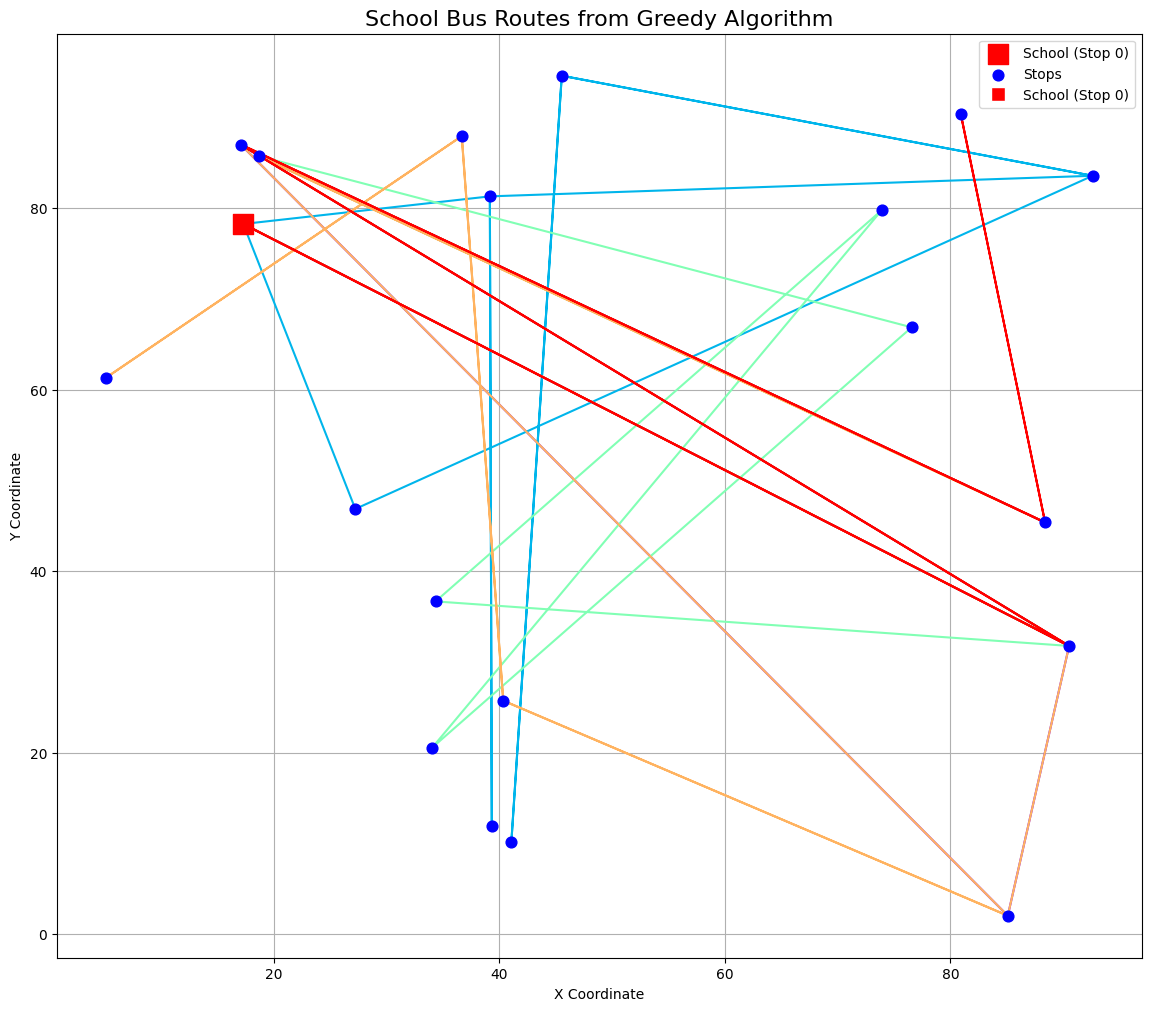

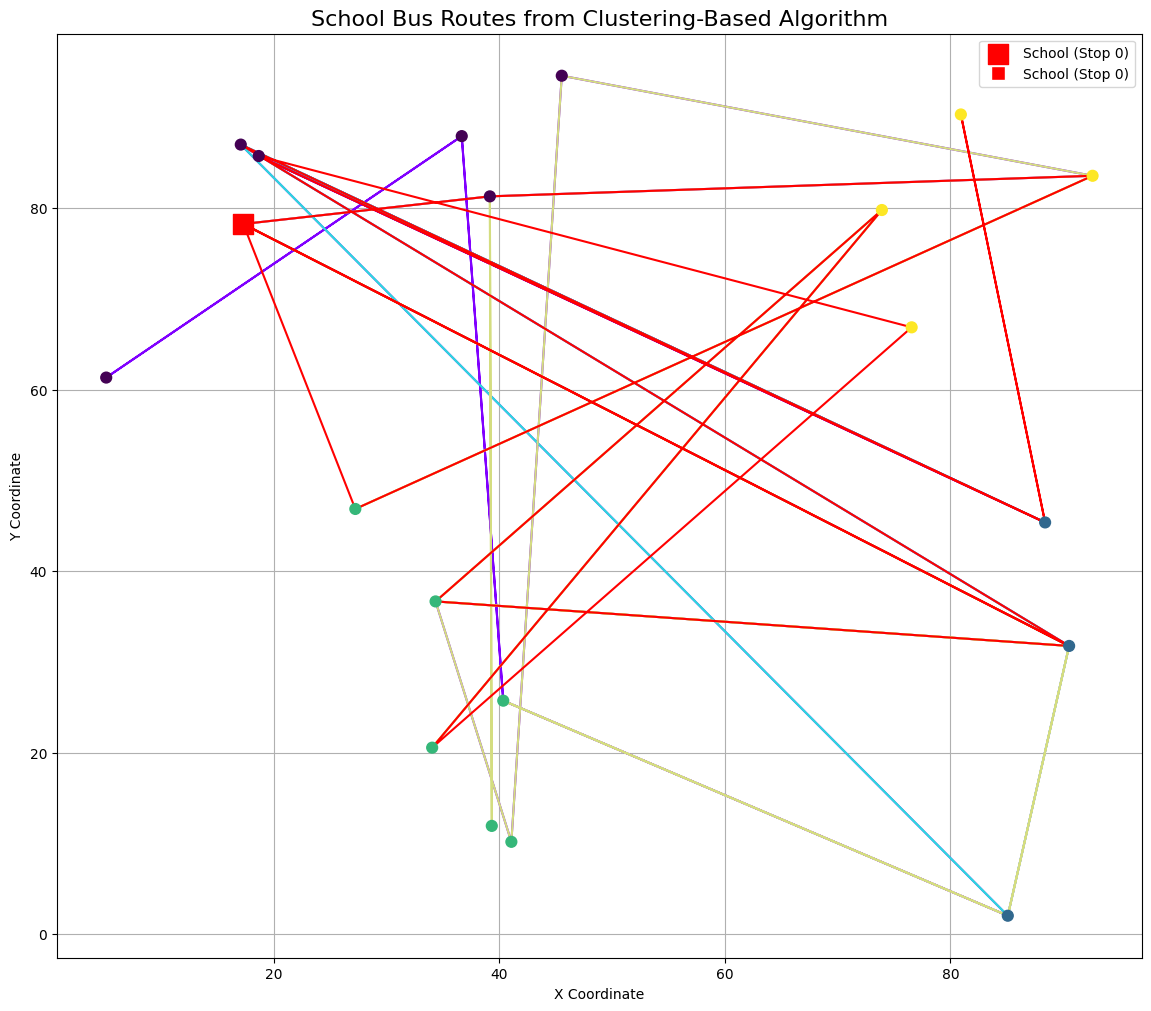

In [5]:
# Simulation Settings
NUM_BUSES = 3
BUS_CAPACITY = 45
AREA_WIDTH = 100
AREA_HEIGHT = 100

# 1. Load Provided Graph Data
adj_list = {
    '1': [['2', 0.2]],
    '2': [['1', 0.2], ['4', 0.3], ['0', 0.4]],
    '4': [['2', 0.3], ['3', 0.2], ['5', 0.2]],
    '0': [['2', 0.4], ['3', 0.5], ['12', 0.2]],
    '3': [['0', 0.5], ['4', 0.2]],
    '5': [['4', 0.2], ['6', 0.3]],
    '6': [['5', 0.3], ['7', 0.3]],
    '7': [['6', 0.3], ['12', 0.2], ['8', 0.3]],
    '12': [['7', 0.2], ['0', 0.2], ['13', 0.2], ['17', 0.2]],
    '8': [['7', 0.3], ['9', 0.3]],
    '9': [['8', 0.3], ['10', 0.3]],
    '10': [['9', 0.3], ['11', 0.3]],
    '11': [['10', 0.3], ['19', 0.2]],
    '19': [['11', 0.2], ['13', 0.2], ['18', 0.3]],
    '13': [['12', 0.2], ['17', 0.2], ['19', 0.2]],
    '17': [['12', 0.2], ['13', 0.2], ['16', 0.3]],
    '14': [['15', 0.1]],
    '15': [['14', 0.1], ['16', 0.1]],
    '16': [['15', 0.1], ['17', 0.3]],
    '18': [['19', 0.3]]
}

# 2. Create Stop Objects and Full Cost Matrix
all_stop_ids = set(adj_list.keys())
for stop_id, neighbors in adj_list.items():
    for neighbor in neighbors:
        all_stop_ids.add(str(neighbor[0]))

stop_coordinates = {stop_id: (random.uniform(0, AREA_WIDTH), random.uniform(0, AREA_HEIGHT)) for stop_id in all_stop_ids}
school_id = '0'
school = Stop(school_id, stop_coordinates[school_id][0], stop_coordinates[school_id][1], 0)

stops = []
for stop_id in all_stop_ids:
    if stop_id != school_id:
        coords = stop_coordinates[stop_id]
        stops.append(Stop(stop_id, coords[0], coords[1], random.randint(5, 15)))

# Create a map for easy lookup of stop objects by ID
stop_map = {s.id: s for s in stops}
stop_map[school.id] = school

# --- CHECK AND GUARANTEE BUS CAPACITY ---
total_students = sum(s.student_count for s in stops)
total_capacity = NUM_BUSES * BUS_CAPACITY
print(f"Total students to pick up: {total_students}")
print(f"Initial total bus capacity: {total_capacity} ({NUM_BUSES} buses * {BUS_CAPACITY} capacity)")
if total_students > total_capacity:
    required_buses = math.ceil(total_students / BUS_CAPACITY)
    print(f"\nWarning: Not enough capacity. Required buses: {required_buses}. Adjusting NUM_BUSES from {NUM_BUSES} to {required_buses}.")
    NUM_BUSES = required_buses
    print(f"New total bus capacity: {NUM_BUSES * BUS_CAPACITY}\n")
else:
    print("Sufficient bus capacity available.\n")

# Build the cost matrix directly from the adjacency list
cost_matrix = {stop_id: {} for stop_id in all_stop_ids}
for stop_id, neighbors in adj_list.items():
    for neighbor in neighbors:
        if len(neighbor) == 2:
            neighbor_id, distance = str(neighbor[0]), neighbor[1]
            cost_matrix[stop_id][neighbor_id] = distance
            if neighbor_id not in cost_matrix: cost_matrix[neighbor_id] = {}
            cost_matrix[neighbor_id][stop_id] = distance

# 3. Run Greedy Algorithm
print("--- Running Greedy Algorithm ---")
greedy_routes = greedy_route_planner(stops, school, cost_matrix, BUS_CAPACITY, stop_map)
total_greedy_cost = sum(calculate_route_cost(r, cost_matrix) for r in greedy_routes)
print(f"Generated {len(greedy_routes)} routes.")
print(f"Total distance: {total_greedy_cost:.2f}\n")

# 4. Run Clustering Algorithm
print("--- Running Clustering-Based Algorithm ---")
clustering_routes, labels = clustering_based_planner(stops, school, NUM_BUSES, cost_matrix, stop_map)
total_clustering_cost = sum(calculate_route_cost(r, cost_matrix) for r in clustering_routes)
print(f"Generated {len(clustering_routes)} routes.")
print(f"Total distance: {total_clustering_cost:.2f}\n")

# 5. Visualize Outputs
visualize_routes(stops, school, greedy_routes, "Greedy Algorithm")
if labels is not None:
    visualize_routes(stops, school, clustering_routes, "Clustering-Based Algorithm", cluster_labels=labels)